In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content

drive  sample_data


In [ ]:
train_path = "/content/drive/MyDrive/mtech/Training"
val_path   = "/content/drive/MyDrive/mtech/Validation"


train_dataset = datasets.ImageFolder(train_path, transform=train_transforms)
val_dataset   = datasets.ImageFolder(val_path, transform=val_transforms)

print("Classes:", train_dataset.classes)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['grade0', 'grade1', 'grade2', 'grade3']
Training images: 2549
Validation images: 280


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels[:5])

torch.Size([32, 3, 224, 224])
tensor([3, 3, 2, 1, 0])


In [ ]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

num_classes = len(train_dataset.classes)
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 179MB/s]


In [ ]:
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()

In [ ]:
import torch
import numpy as np

num_epochs = 15
best_val_acc = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    # -------- TRAIN --------
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # -------- VALIDATION --------
    model.eval()
    val_running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc = 100 * correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% "
          f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # -------- SAVE BEST MODEL --------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_resnet50_model.pth")
        print("Model Saved!")

print("Best Validation Accuracy:", best_val_acc)

Epoch [1/15] Train Loss: 0.1068 | Train Acc: 96.27% | Val Loss: 0.1404 | Val Acc: 93.21%
Model Saved!
Epoch [2/15] Train Loss: 0.0968 | Train Acc: 96.86% | Val Loss: 0.1489 | Val Acc: 94.29%
Model Saved!
Epoch [3/15] Train Loss: 0.0782 | Train Acc: 97.41% | Val Loss: 0.1677 | Val Acc: 93.57%
Epoch [4/15] Train Loss: 0.0665 | Train Acc: 98.39% | Val Loss: 0.1583 | Val Acc: 94.29%
Epoch [5/15] Train Loss: 0.0595 | Train Acc: 98.27% | Val Loss: 0.1593 | Val Acc: 94.29%
Epoch [6/15] Train Loss: 0.0410 | Train Acc: 98.86% | Val Loss: 0.1607 | Val Acc: 93.57%
Epoch [7/15] Train Loss: 0.0389 | Train Acc: 99.22% | Val Loss: 0.1822 | Val Acc: 93.21%
Epoch [8/15] Train Loss: 0.0331 | Train Acc: 99.18% | Val Loss: 0.1612 | Val Acc: 93.93%
Epoch [9/15] Train Loss: 0.0304 | Train Acc: 99.41% | Val Loss: 0.1684 | Val Acc: 94.29%
Epoch [10/15] Train Loss: 0.0279 | Train Acc: 99.22% | Val Loss: 0.1900 | Val Acc: 94.29%
Epoch [11/15] Train Loss: 0.0273 | Train Acc: 99.41% | Val Loss: 0.1698 | Val Acc: 

In [ ]:
model.load_state_dict(torch.load("best_resnet50_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

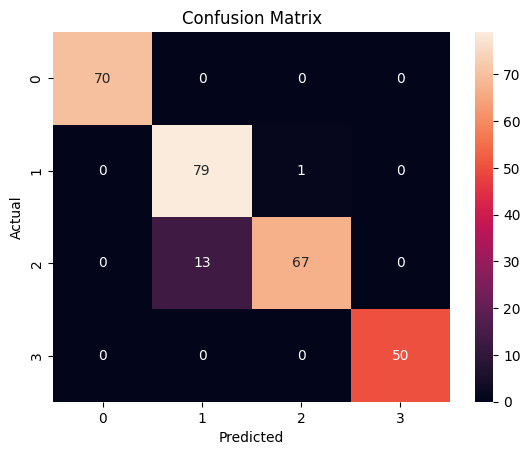

              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.86      0.99      0.92        80
      grade2       0.99      0.84      0.91        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.95       280
   macro avg       0.96      0.96      0.96       280
weighted avg       0.96      0.95      0.95       280



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))

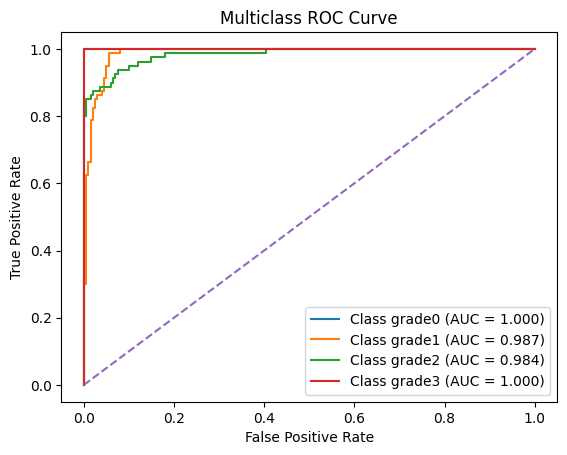

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

num_classes = len(train_dataset.classes)

# Convert labels to one-hot
all_labels_bin = label_binarize(all_labels, classes=range(num_classes))

# Collect probabilities for all classes
all_probs = []

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

# Plot ROC for each class
plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {train_dataset.classes[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_auc_score

macro_auc = roc_auc_score(all_labels_bin, all_probs, average="macro")
micro_auc = roc_auc_score(all_labels_bin, all_probs, average="micro")

print("Macro AUC:", macro_auc)
print("Micro AUC:", micro_auc)

Macro AUC: 0.992703125
Micro AUC: 0.9937712585034013


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[70  0  0  0]
 [ 0 79  1  0]
 [ 0 13 67  0]
 [ 0  0  0 50]]


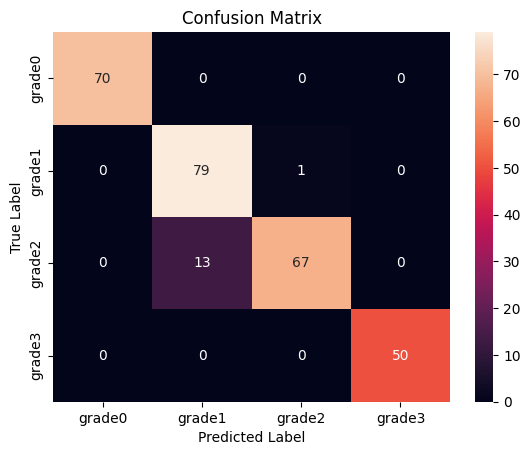

In [ ]:
plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

              precision    recall  f1-score   support

      grade0       1.00      1.00      1.00        70
      grade1       0.86      0.99      0.92        80
      grade2       0.99      0.84      0.91        80
      grade3       1.00      1.00      1.00        50

    accuracy                           0.95       280
   macro avg       0.96      0.96      0.96       280
weighted avg       0.96      0.95      0.95       280



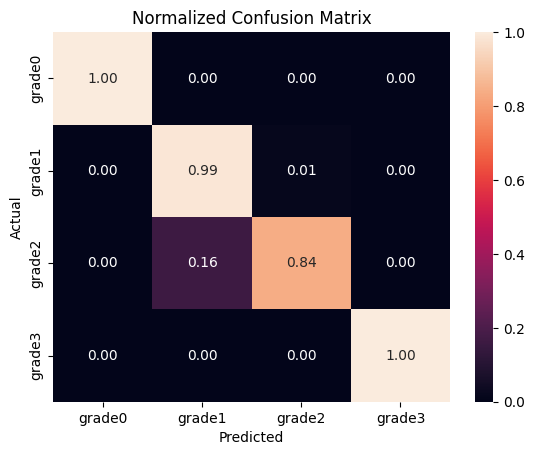

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(cm_normalized,
            annot=True,
            fmt='.2f',
            xticklabels=train_dataset.classes,
            yticklabels=train_dataset.classes)

plt.title("Normalized Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

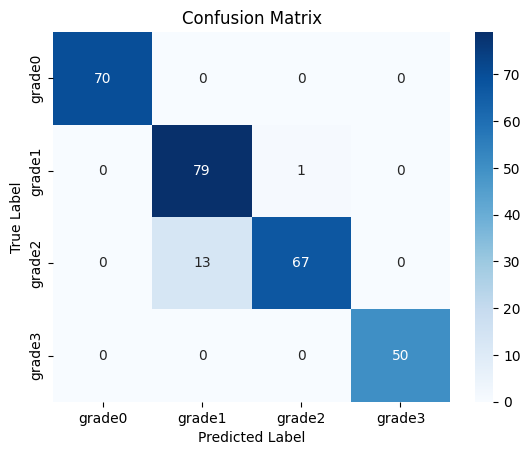

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',  # 🔵 Blue color map
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

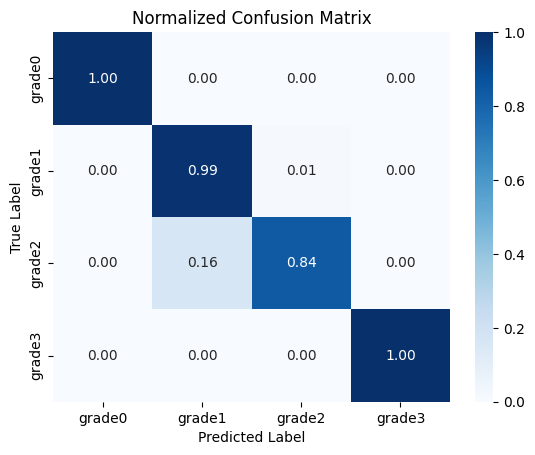

In [ ]:
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure()
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',  # 🔵 Blue color map
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()